# Initial training using random split

### (a) Load model-ready dataset and do train-test split

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # clean plot style

COMPLETE_DATASET = 'datasets/YEAR_COMPLETE_DATASET.csv'
MODEL_READY_DATASET = 'datasets/MODEL_READY_DATASET5.csv'

# Load model-ready dataset
try:
    df = pd.read_csv(MODEL_READY_DATASET)
except NameError:
    print(f"Error: MODEL_READY_DATASET does not exist yet")
    print("Please run the preprocessing notebook")
    raise SystemExit

# Separate Features (X) and Target (y)
X = df.drop(columns=['target_fuel_price_tomorrow'])
y = df['target_fuel_price_tomorrow']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### (b) Train using Random Forest and Linear Regressor

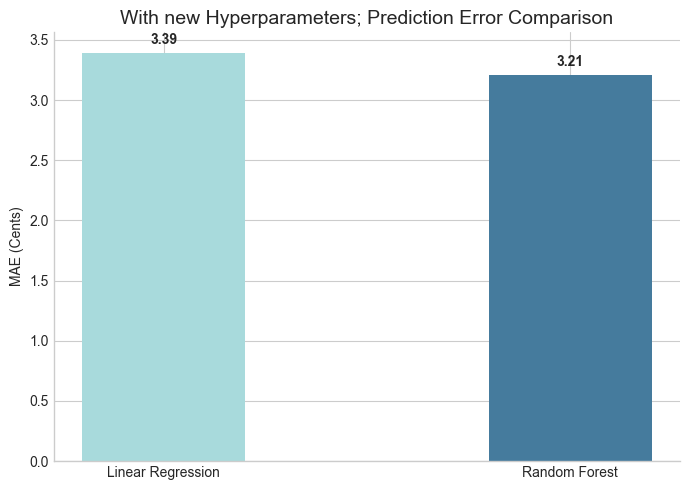

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler # <-- Import Scaler

# === Train RF model on unscaled features ===
rf_model = RandomForestRegressor(
    n_estimators=300, 
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=30,
    max_features=0.6,
    bootstrap=True,
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# === Train LR model on SCALED features ===

# Initialize the standardizer (Z-score normalization)
scaler = StandardScaler()

# CRITICAL: Fit only on the past training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# CRITICAL: Use the training parameters to transform the unseen future test vault
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)
# ==========================================

from sklearn.metrics import mean_absolute_error

rf_mae = mean_absolute_error(y_test, rf_predictions)
lr_mae = mean_absolute_error(y_test, lr_predictions)

plt.figure(figsize=(7, 5))
results = {'Linear Regression': lr_mae, 'Random Forest': rf_mae}
colors = ['#A8DADC', '#457B9D']

bars = plt.bar(results.keys(), results.values(), color=colors, width=0.4)

# Scientific styling
plt.title('With new Hyperparameters; Prediction Error Comparison', fontsize=14)
plt.ylabel('MAE (Cents)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### (c) Compare the two models

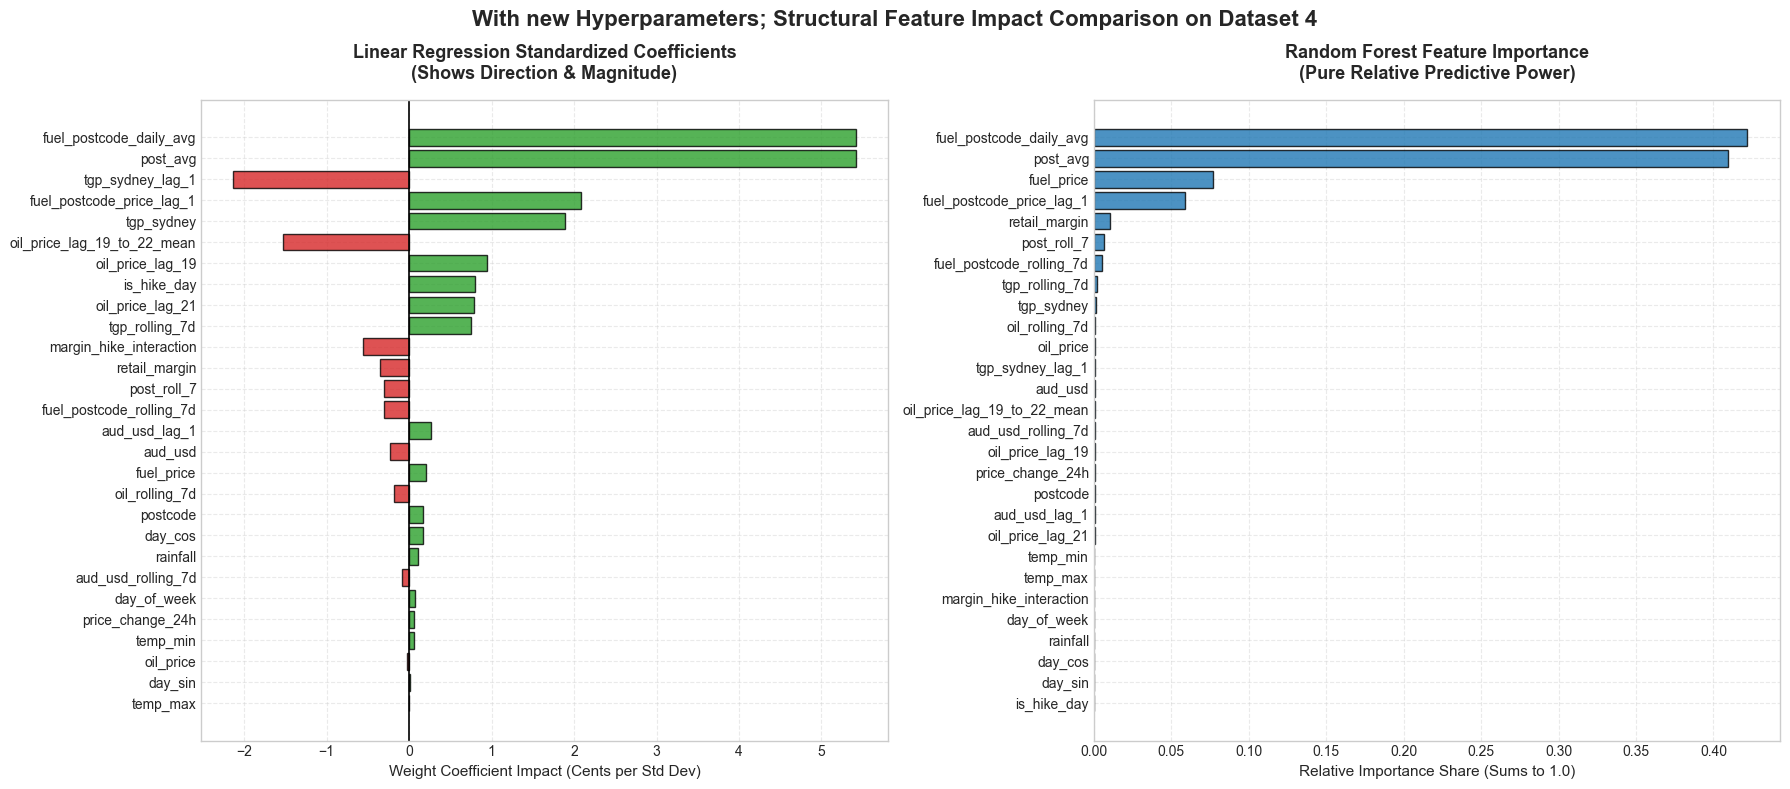

========================================= LINEAR REGRESSION WEIGHTS =========================================
                    Feature  Coefficient
    fuel_postcode_daily_avg     5.422348
                   post_avg     5.422348
           tgp_sydney_lag_1    -2.141112
  fuel_postcode_price_lag_1     2.081770
                 tgp_sydney     1.886639
oil_price_lag_19_to_22_mean    -1.530362
           oil_price_lag_19     0.938875
                is_hike_day     0.794701
           oil_price_lag_21     0.784894
             tgp_rolling_7d     0.748890
    margin_hike_interaction    -0.553691
              retail_margin    -0.354387
                post_roll_7    -0.299871
   fuel_postcode_rolling_7d    -0.299871
              aud_usd_lag_1     0.261800
                    aud_usd    -0.227244
                 fuel_price     0.201542
             oil_rolling_7d    -0.180011
                   postcode     0.171688
                    day_cos     0.169874
                   rainfall  

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Extract Linear Regression Coefficients
lr_features = X_train.columns
lr_coefs = lr_model.coef_

# Create a DataFrame and sort by absolute magnitude for clean visualization
lr_importance = pd.DataFrame({
    'Feature': lr_features,
    'Coefficient': lr_coefs,
    'Absolute': np.abs(lr_coefs)
}).sort_values(by='Absolute', ascending=True) # Ascending for horizontal bar plot entry

# 2. Extract Random Forest Feature Importances
rf_importances = rf_model.feature_importances_

rf_importance = pd.DataFrame({
    'Feature': lr_features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=True)

# 3. Construct Side-by-Side Horizontal Bar Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Panel 1: Linear Regression Coefficients ---
# We map colors: Red for negative price impact, Green for positive price impact
colors = ['#d62728' if c < 0 else '#2ca02c' for c in lr_importance['Coefficient']]

axes[0].barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1.2)
axes[0].set_title('Linear Regression Standardized Coefficients\n(Shows Direction & Magnitude)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Weight Coefficient Impact (Cents per Std Dev)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Panel 2: Random Forest Feature Importance ---
axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='#1f77b4', edgecolor='black', alpha=0.8)
axes[1].set_title('Random Forest Feature Importance\n(Pure Relative Predictive Power)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Relative Importance Share (Sums to 1.0)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

# 4. Global Plot Adjustments
plt.suptitle('With new Hyperparameters; Structural Feature Impact Comparison on Dataset 4', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 5. Print out the raw tabular values underneath for precise inspection
print("="*41 + " LINEAR REGRESSION WEIGHTS " + "="*41)
print(lr_importance[['Feature', 'Coefficient']].sort_values(by='Coefficient', key=abs, ascending=False).to_string(index=False))
print("\n" + "="*43 + " RANDOM FOREST IMPURITY " + "="*43)
print(rf_importance.sort_values(by='Importance', ascending=False).to_string(index=False))

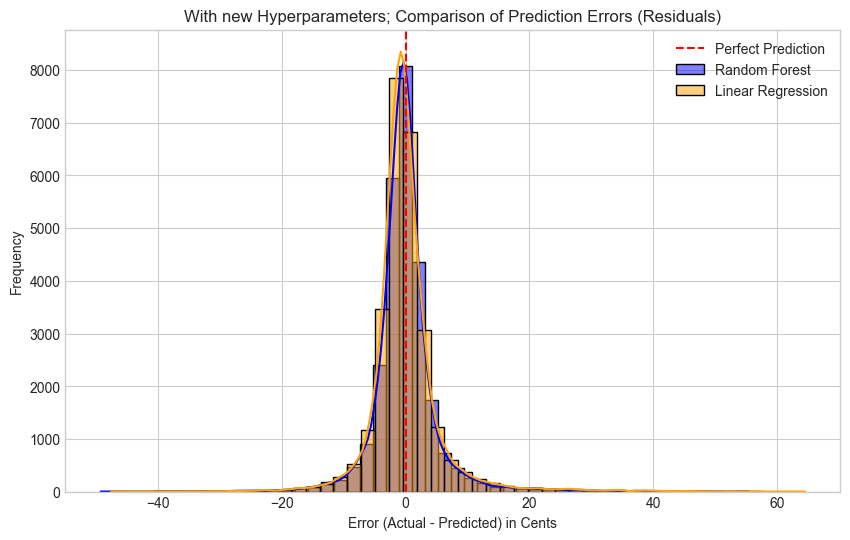

In [4]:
# Calculate residuals
rf_residuals = y_test - rf_predictions
lr_residuals = y_test - lr_predictions

plt.figure(figsize=(10, 6))

# Plot Random Forest Residuals
sns.histplot(rf_residuals, kde=True, bins=50, color='blue', label='Random Forest', alpha=0.5)

# Plot Linear Regression Residuals
sns.histplot(lr_residuals, kde=True, bins=50, color='orange', label='Linear Regression', alpha=0.5)

# Formatting
plt.title('With new Hyperparameters; Comparison of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in Cents')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Perfect Prediction')
plt.legend() # This adds the labels to the plot
plt.show()

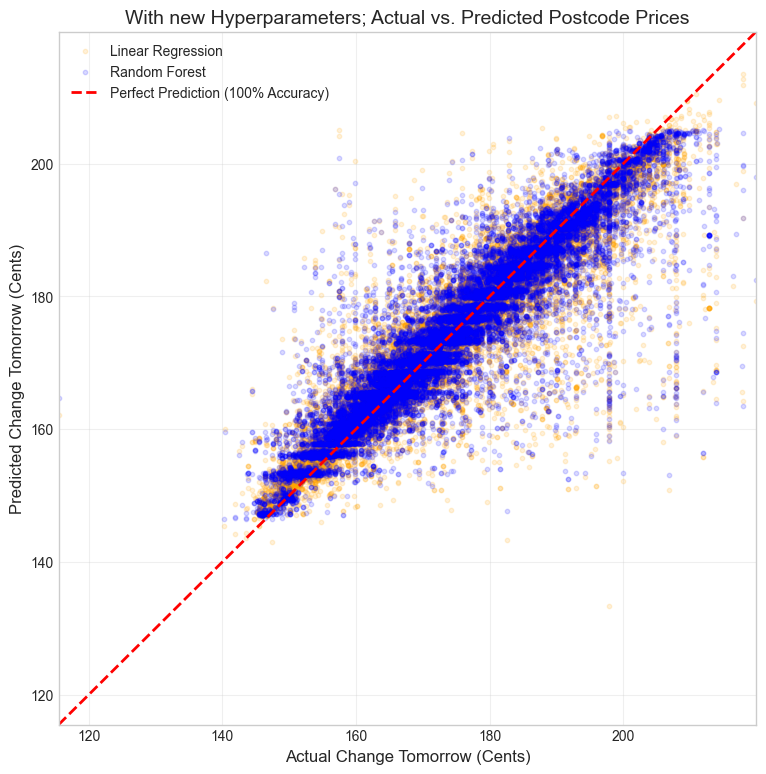

In [5]:
plt.figure(figsize=(9, 9))

# Plot Linear Regression
plt.scatter(y_test, lr_predictions, alpha=0.15, color='orange', label='Linear Regression', s=10)

# Plot Random Forest
plt.scatter(y_test, rf_predictions, alpha=0.15, color='blue', label='Random Forest', s=10)

# Perfect Prediction Line
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, 'r--', lw=2, label='Perfect Prediction (100% Accuracy)')

# Refined Labels for the Delta approach
plt.title('With new Hyperparameters; Actual vs. Predicted Postcode Prices', fontsize=14)
plt.xlabel('Actual Change Tomorrow (Cents)', fontsize=12)
plt.ylabel('Predicted Change Tomorrow (Cents)', fontsize=12)

# Add a horizontal and vertical line at zero to show the "No Change" boundary
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)

plt.xlim(line_range)
plt.ylim(line_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

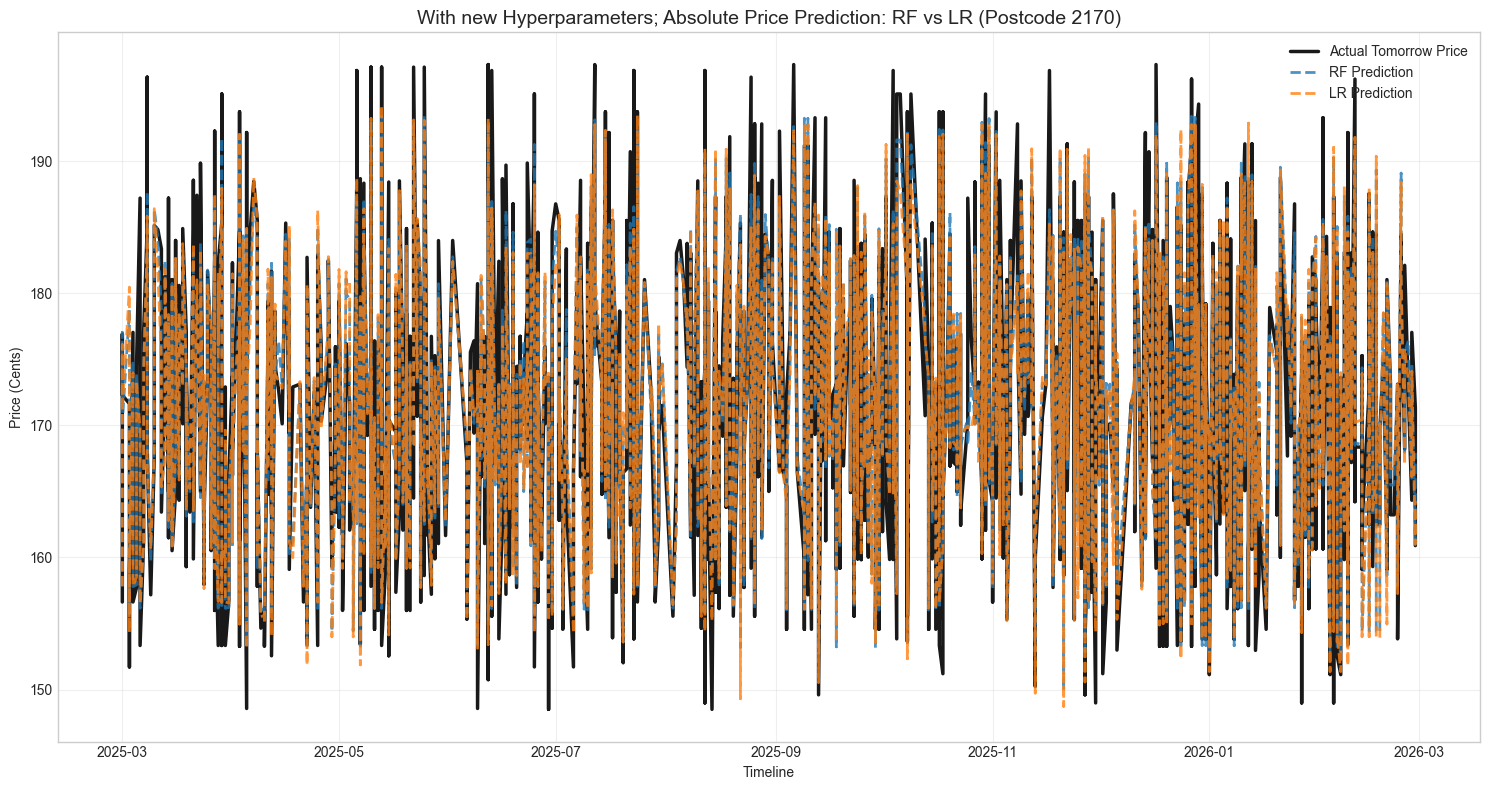

In [6]:
# 1. Reconstruct the test results with dates
# Assuming 'df_final' or your source CSV still exists with the 'date' column
df_source = pd.read_csv(COMPLETE_DATASET, parse_dates=['date'])

comparison_df = pd.DataFrame({
    'date': df_source.loc[X_test.index, 'date'],
    'postcode': X_test['postcode'],
    'actual': y_test,
    'rf_pred': rf_predictions,
    'lr_pred': lr_predictions
})

# 2. Pick a sample postcode
sample_postcode = comparison_df['postcode'].mode()[0]
plot_data = comparison_df[comparison_df['postcode'] == sample_postcode].sort_values('date')

# 3. Create the Comparison Plot
plt.figure(figsize=(15, 8))

# Actual price
plt.plot(plot_data['date'], plot_data['actual'], 
         label='Actual Tomorrow Price', color='black', lw=2.5, linestyle='-', alpha=0.9)

# Random Forest
plt.plot(plot_data['date'], plot_data['rf_pred'], 
         label='RF Prediction', color='#1f77b4', linestyle='--', alpha=0.8, lw=2)

# Linear Regression
plt.plot(plot_data['date'], plot_data['lr_pred'], 
         label='LR Prediction', color='#ff7f0e', linestyle='--', alpha=0.8, lw=2)

# REMOVED: plt.axhline(0) - No longer needed for absolute prices

plt.title(f'With new Hyperparameters; Absolute Price Prediction: RF vs LR (Postcode {sample_postcode})', fontsize=14)
plt.ylabel('Price (Cents)') # Updated label
plt.xlabel('Timeline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

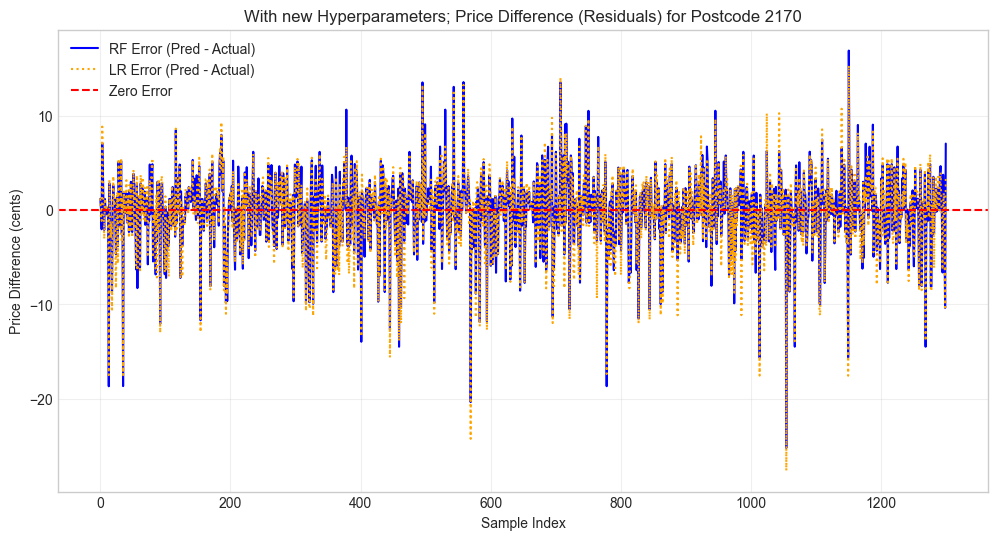

In [7]:
# Calculate the differences (Residuals)
plot_data['rf_diff'] = plot_data['rf_pred'] - plot_data['actual']
plot_data['lr_diff'] = plot_data['lr_pred'] - plot_data['actual']

plt.figure(figsize=(12, 6))

# Plotting the difference from zero
plt.plot(plot_data['rf_diff'].values, label='RF Error (Pred - Actual)', color='blue', linestyle="-")
plt.plot(plot_data['lr_diff'].values, label='LR Error (Pred - Actual)', color='orange', linestyle=":")

# Add a zero line to represent perfect prediction
plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')

plt.title(f'With new Hyperparameters; Price Difference (Residuals) for Postcode {sample_postcode}')
plt.xlabel('Sample Index')
plt.ylabel('Price Difference (cents)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
